In [1]:
!pip install finance-datareader

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.9/53.9 kB 2.7 MB/s eta 0:00:00


In [2]:
!pip install --upgrade finance-datareader

In [3]:
import FinanceDataReader as fdr
import pandas as pd

In [5]:
# fdr.StockListing(시장코드)   # 시장코드: 'KOSPI' 또는 'KOSDAQ'

In [6]:
# 코스피 종목 정보 수집
df = fdr.StockListing('KOSPI')

# 종목코드, 종목명, 시가총액만 선택
df = df[['Code','Name','Marcap']]

# 최초 5건 화면 출력
df.head()

,Code,Name,Marcap
0,005930,삼성전자,1745114164488000
1,000660,SK하이닉스,1597165999965000
2,402340,SK스퀘어,195562328052000
3,005935,삼성전자우,160153292118800
4,009150,삼성전기,140200067392000


In [7]:
# 코스닥 종목 정보 수집
df = fdr.StockListing('KOSDAQ')

# 종목코드, 종목명, 시가총액만 선택
df = df[['Code','Name','Marcap']]

# 최초 5건 화면 출력
df.head()

,Code,Name,Marcap
0,196170,알테오젠,17924631733500
1,247540,에코프로비엠,11876614687600
2,086520,에코프로,11486662459200
3,277810,레인보우로보틱스,9108233331000
4,036930,주성엔지니어링,9073114819200


In [9]:
# KOSPI 종목 리스트에서 종목코드(Code), 종목명(Name), 시가총액(Marcap)만 선별
df = fdr.StockListing('KOSPI')[['Code', 'Name', 'Marcap']]

# 우선주, 최근상장 종목, 리츠 제외 (df는 시가총액 상위 순으로 정렬)
df = df.query("Name not in ['삼성전자우', '현대차2우B', '미래에셋증권2우B','삼성에피스홀딩스','맥쿼리인프라']")

# 시가총액 상위 200개 종목 추출
df = df.iloc[:200]

# 인덱스 번호 재설정 (0부터 순차 부여)
df = df.reset_index(drop=True)

# 결과 데이터 최초 5건 확인
df.head()

,Code,Name,Marcap
0,005930,삼성전자,1745114164488000
1,000660,SK하이닉스,1597165999965000
2,402340,SK스퀘어,195562328052000
3,009150,삼성전기,140200067392000
4,005380,현대차,97259938850000


In [10]:
#fdr.DataReader(종목코드, 수집시작일, 수집최종일)

In [11]:
fdr.DataReader('005930', '20250416', '20250418')   # 삼성전자의 25.4.16~25.4.18 주가

,Open,High,Low,Close,Volume,Change
Date,,,,,,
2025-04-16,56000,56200,54500,54700,14437025,-0.033569
2025-04-17,54700,55300,54500,55100,10867069,0.007313
2025-04-18,55300,55600,54900,55300,5848342,0.003630


In [12]:
df = fdr.DataReader('005930', '20240418', '20250418') # 삼성전자 1년치 주가 데이터

mom_1d = ( df.iloc[-1]['Close'] / df.iloc[-2]['Close'] - 1 )  * 100    # 전일
mom_1w = ( df.iloc[-1]['Close'] / df.iloc[-5]['Close'] - 1 )  * 100   # 주간
mom_1m = ( df.iloc[-1]['Close'] / df.iloc[-20]['Close'] - 1 )  * 100  # 월간
mom_1y = ( df.iloc[-1]['Close'] / df.iloc[-240]['Close'] - 1 )  * 100  # 연간

In [13]:
mom_1d  # 전일

np.float64(0.3629764065335772)

In [14]:
mom_1w  # 전주

np.float64(-1.6014234875444844)

In [15]:
mom_1m  # 전월

np.float64(-8.595041322314046)

In [16]:
mom_1y  # 전년

np.float64(-26.75496688741722)

<Axes: xlabel='Date'>

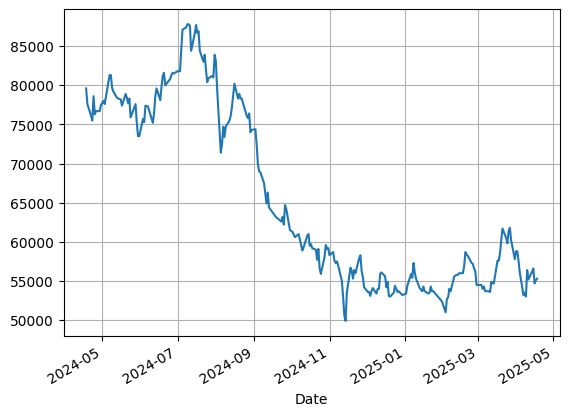

In [17]:
df['Close'].plot(kind='line', grid=True)

In [18]:
df['Volume'].rolling(window=5).mean()  # 5일 이동평균 계산

,Volume
Date,
2024-04-18,NaN
2024-04-19,NaN
2024-04-22,NaN
2024-04-23,NaN
2024-04-24,24808215.8
...,...
2025-04-14,19168214.0
2025-04-15,15861373.0
2025-04-16,14633386.0


In [19]:
vol_short = df['Volume'].rolling(window=5).mean().iloc[-1] # 거래량 5일이동평균의 마지막 데이터
vol_long = df['Volume'].rolling(window=20).mean().iloc[-1] # 거래량20일이동평균의 마지막 데이터
vol = ( vol_short / vol_long - 1) * 100 # 거래량 변동성 계산

In [20]:
vol

np.float64(-37.89028795307283)

In [23]:
#fdr.SnapDataReader('NAVER/FINSTATE-2Y/종목코드')   #  연간 K-IFRS 연결 기준

In [24]:
# 재무제표 데이터 추출 (삼성전자, 연간 K-IFRS 연결 기준)
data = fdr.SnapDataReader('NAVER/FINSTATE-2Y/005930')

# 미래 추정치 제외 (영업이익 결측치 삭제)
data = data.dropna(subset='영업이익')

# PER, PBR 출력
data[['PER(배)', 'PBR(배)']]

주요재무정보,PER(배),PBR(배)
날짜,,
2021-12-01,13.33,1.74
2022-12-01,6.75,1.06
2023-12-01,34.43,1.47
2024-12-01,10.49,0.89
2025-12-01,17.89,1.82


In [25]:
print(data['PER(배)'].iloc[-1])

print(data['PBR(배)'].iloc[-1])

17.89
1.82


In [26]:
# 대상 컬럼 지정
cols = ['매출액', '영업이익', '당기순이익', 'ROE(%)']

# 재무 데이터 추출 : 분기 K-IFRS 연결 기준
data = fdr.SnapDataReader('NAVER/FINSTATE-2Q/005930')[cols]

# 미래 추정치 제외 : 영업이익 결측치 삭제
data = data.dropna(subset='영업이익')

# 결과 화면 출력
data

주요재무정보,매출액,영업이익,당기순이익,ROE(%)
날짜,,,,
2025-03-01,791405.0,66853.0,82229.0,9.23
2025-06-01,745663.0,46761.0,51164.0,7.97
2025-09-01,860617.0,121661.0,122257.0,8.33
2025-12-01,938374.0,200737.0,196417.0,10.78
2026-03-01,1338734.0,572328.0,472253.0,18.85


In [27]:
data[['매출액','영업이익','당기순이익']].pct_change()*100

주요재무정보,매출액,영업이익,당기순이익
날짜,,,
2025-03-01,NaN,NaN,NaN
2025-06-01,-5.779847,-30.053999,-37.778643
2025-09-01,15.416348,160.176215,138.951216
2025-12-01,9.035030,64.997000,60.659103
2026-03-01,42.665291,185.113357,140.433873


In [28]:
(data[['매출액','영업이익','당기순이익']].pct_change()*100).iloc[-1].to_list()

[42.66529123782201, 185.11335727842896, 140.43387283178137]

In [29]:
data['ROE(%)'].iloc[-1]

np.float64(18.85)

In [30]:
!pip install MultiFactor

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 68.0/68.0 kB 7.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 75.2 MB/s eta 0:00:00


In [31]:
!pip install --upgrade MultiFactor

In [32]:
from MultiFactor import MultiFactorKR  # 라이브러리 불러오기
mf_kr = MultiFactorKR(N=5)  # 멀티팩터 객체 생성: 시가총액 상위 5개 종목 추출
mf_kr.get_score()         # 멀티팩터 종합 점수 산출

(1/5) 종목코드 생성
종목 추출 건수  5

(2/5) 모멘텀 지표 생성

(3/5) 밸류 지표 생성
0/5 진행 중... (삼성전자)

(4/5) 퀄리티 지표 생성
0/5 진행 중... (삼성전자)

(5/5) 멀티팩터 마스터 생성


,scode,sname,mom_price,mom_vol,PER,PBR,revenue_rate,oper_income_rate,net_income_rate,ROE,...,모멘텀_거래량,밸류_PER,밸류_PBR,퀄리티_ROE,퀄리티_매출증가,퀄리티_영업이익증가,퀄리티_순이익증가,종합점수,종합순위,종합순위_퍼센트
0,402340,SK스퀘어,193.891515,3.234812,5.54,1.73,155.767920,167.171212,155.567762,54.32,...,20.0,20.0,40.0,40.0,20.0,40.0,40.0,32.5,1.0,20.0
1,000660,SK하이닉스,171.084306,-5.122150,11.03,3.73,60.163221,96.197625,164.632691,61.17,...,60.0,60.0,100.0,20.0,40.0,60.0,20.0,52.5,2.0,40.0
2,005930,삼성전자,94.259786,-4.590059,17.89,1.82,42.665291,185.113357,140.433873,18.85,...,40.0,80.0,60.0,60.0,60.0,20.0,60.0,57.5,3.0,60.0
3,005380,현대차,22.592246,-23.579838,7.65,0.61,-1.920852,48.324879,118.319257,7.54,...,100.0,40.0,20.0,100.0,100.0,80.0,80.0,77.5,4.0,80.0
4,009150,삼성전기,328.632720,-19.282895,27.07,1.97,10.578547,17.160752,11.174659,8.80,...,80.0,100.0,80.0,80.0,80.0,100.0,100.0,80.0,5.0,100.0


In [33]:
from MultiFactor import MultiFactorKR  # 라이브러리 불러오기
mf_kr = MultiFactorKR(N=10)  # 멀티팩터 객체 생성: 시가총액 상위 10개 종목 추출
df = mf_kr.get_score()  # 멀티팩터 종합점수 산출하여 데이터프레임(df)에 저장

(1/5) 종목코드 생성
종목 추출 건수  10

(2/5) 모멘텀 지표 생성

(3/5) 밸류 지표 생성
0/10 진행 중... (삼성전자)

(4/5) 퀄리티 지표 생성
0/10 진행 중... (삼성전자)

(5/5) 멀티팩터 마스터 생성


In [34]:
cols = ['scode', 'sname', 'mom_price', 'mom_vol', 'PER', 'PBR',
        'revenue_rate', 'oper_income_rate', 'net_income_rate', 'ROE']  #  종합지표 원본 컬럼명 정의
df[cols].head()  # 상위 5개 종목 결과 출력

,scode,sname,mom_price,mom_vol,PER,PBR,revenue_rate,oper_income_rate,net_income_rate,ROE
0,402340,SK스퀘어,194.660361,3.261162,5.54,1.73,155.767920,167.171212,155.567762,54.32
1,000660,SK하이닉스,171.084306,-5.122150,11.03,3.73,60.163221,96.197625,164.632691,61.17
2,005930,삼성전자,94.259786,-4.590059,17.89,1.82,42.665291,185.113357,140.433873,18.85
3,032830,삼성생명,53.907596,-12.378296,12.86,0.44,42.480737,1324.763903,465.056948,5.25
4,005380,현대차,22.592246,-23.572230,7.65,0.61,-1.920852,48.324879,118.319257,7.54


In [35]:
cols = ['scode', 'sname',  '모멘텀_주가', '모멘텀_거래량', '밸류_PER', '밸류_PBR',
             '퀄리티_ROE', '퀄리티_매출증가', '퀄리티_영업이익증가', '퀄리티_순이익증가']  #  종합지표 순위 컬럼명 정의
df[cols].head()  # 상위 5개 종목 결과 출력

,scode,sname,모멘텀_주가,모멘텀_거래량,밸류_PER,밸류_PBR,퀄리티_ROE,퀄리티_매출증가,퀄리티_영업이익증가,퀄리티_순이익증가
0,402340,SK스퀘어,20.0,20.0,10.0,40.0,20.0,20.0,30.0,30.0
1,000660,SK하이닉스,30.0,50.0,40.0,80.0,10.0,30.0,40.0,20.0
2,005930,삼성전자,40.0,40.0,60.0,50.0,50.0,40.0,20.0,40.0
3,032830,삼성생명,50.0,70.0,50.0,10.0,90.0,50.0,10.0,10.0
4,005380,현대차,70.0,100.0,20.0,20.0,70.0,90.0,70.0,50.0


In [36]:
cols = ['scode', 'sname', '종합점수', '종합순위', '종합순위_퍼센트']  #  종합점수/순위 컬럼명 정의
df[cols].head()  # 상위 5개 종목 결과 출력

,scode,sname,종합점수,종합순위,종합순위_퍼센트
0,402340,SK스퀘어,23.75,1.0,10.0
1,000660,SK하이닉스,37.50,2.0,20.0
2,005930,삼성전자,42.50,3.5,35.0
3,032830,삼성생명,42.50,3.5,35.0
4,005380,현대차,61.25,5.0,50.0


In [37]:
# df(데이터프레임)의 종목들을 종합점수 상위 순으로 3개(Ngroup=3)의 그룹으로 나눔
mf_kr.get_Ngroup(df, Ngroup=3)

# [출력 결과]
# 1 : SK스퀘어, SK하이닉스, 삼성전자, 기아
# 2 : KB금융, 한화에어로스페이스, 현대차
# 3 : 두산에너빌리티, LG에너지솔루션, 삼성바이오로직스

1 : SK스퀘어, SK하이닉스, 삼성전자, 삼성생명
2 : 현대차, 삼성전기, 삼성물산
3 : 삼성바이오로직스, HD현대중공업, LG에너지솔루션


In [38]:
# 1. 라이브러리 불러오기
from MultiFactor import MultiFactorKR

# 2. 멀티팩터 객체 생성: 시가총액 상위 100 종목
mf_kr = MultiFactorKR(N=100)

# 3. 멀티팩터 종합점수 산출하여 데이터프레임(df)에 저장
df = mf_kr.get_score()

# 4. 분석된 종목들을 종합 점수 순으로 10개(Ngroup=10) 그룹으로 나누어 요약 출력
mf_kr.get_Ngroup(df, Ngroup=10)

# [출력 결과]
# 1 : SK스퀘어, SK하이닉스, 삼성E&A, HD현대, 에이피알, 한국금융지주, 삼성전자, LG이노텍, 키움증권, LS ELECTRIC
# 2 : 효성중공업, NH투자증권, 이수페타시스, 삼성물산, 삼성증권, HD현대일렉트릭, LG씨엔에스, LS, HD한국조선해양, 현대건설
# 3 : 코오롱티슈진, 한화, 고려아연, 하나금융지주, JB금융지주, 미래에셋증권, KB금융, 삼천당제약, 기업은행, 엘앤에프
# 4 : DB손해보험, 기아, 한전기술, 셀트리온, 우리금융지주, 펩트론, BNK금융지주, 대우건설, 한국항공우주, 현대글로비스
# 5 : 삼성생명, 신한지주, HD현대중공업, 한화에어로스페이스, 현대모비스, 한화솔루션, 현대차, 삼양식품, 삼성카드, 에이비엘바이오
# 6 : SK바이오팜, LG유플러스, 한미약품, S-Oil, GS, KT, 한화오션, 삼성화재, 두산, 삼성전기
# 7 : SK텔레콤, 카카오뱅크, 한국전력, 한국타이어앤테크놀로지, HMM, 삼성중공업, 포스코인터내셔널, SK, 현대로템, 카카오페이
# 8 : 대한항공, 현대오토에버, CJ, LIG넥스원, 삼성SDI, HD건설기계, HD현대마린솔루션, 두산에너빌리티, 크래프톤, 하이브
# 9 : HLB, 삼성에스디에스, KT&G, 아모레퍼시픽, 유한양행, 한화시스템, SK이노베이션, LG전자, 삼성에피스홀딩스, NAVER
# 10 : LG, 레인보우로보틱스, 한미반도체, POSCO홀딩스, LG에너지솔루션, 카카오, LG화학, 삼성바이오로직스, 한진칼, 포스코퓨처엠

(1/5) 종목코드 생성
종목 추출 건수  100

(2/5) 모멘텀 지표 생성

(3/5) 밸류 지표 생성
0/100 진행 중... (삼성전자)
50/100 진행 중... (삼성에스디에스)
추출오류 :  카카오뱅크
추출오류 :  코오롱티슈진

(4/5) 퀄리티 지표 생성
0/100 진행 중... (삼성전자)
50/100 진행 중... (삼성에스디에스)
추출오류 :  카카오뱅크
추출오류 :  코오롱티슈진

(5/5) 멀티팩터 마스터 생성
1 : SK스퀘어, 한국금융지주, 하나금융지주, SK하이닉스, SK, 삼성생명, GS, 삼성증권, BNK금융지주, 삼성전자
2 : KB금융, LS, 키움증권, HD현대, 신한지주, 우리금융지주, 한국전력, 삼성화재, 대한항공, NH투자증권
3 : 한화, S-Oil, 현대차, 미래에셋증권, HD건설기계, 대덕전자, NC, 기업은행, 기아, 한국타이어앤테크놀로지
4 : KT, 에이피알, 코오롱티슈진, 삼성E&A, 크래프톤, 이수페타시스, 코웨이, HD현대중공업, 삼성물산, 아모레퍼시픽
5 : 삼성전기, 오리온, 산일전기, KT&G, DB손해보험, 삼양식품, 고려아연, 현대글로비스, LS ELECTRIC, 포스코인터내셔널
6 : SK텔레콤, HD한국조선해양, 삼성바이오로직스, 현대모비스, SK이노베이션, LG유플러스, 두산밥캣, 삼성카드, POSCO홀딩스, 대한전선
7 : 한미약품, 삼성에피스홀딩스, 한화오션, HD현대마린솔루션, LG이노텍, 카카오뱅크, 한화솔루션, HD현대일렉트릭, 현대건설, 대우건설
8 : 삼성SDI, 효성중공업, SK바이오팜, 한화에어로스페이스, 현대로템, 신세계, LG전자, LG, 삼성중공업, HMM
9 : 한진칼, LG화학, LG씨엔에스, 한화시스템, 두산, LG에너지솔루션, LIG디펜스앤에어로스페이스, 셀트리온, 한국항공우주, NAVER
10 : 삼성에스디에스, 한미반도체, 포스코퓨처엠, 유한양행, 하이브, 현대오토에버, 두산에너빌리티, 카카오, HLB, 레인보우로보틱스


In [39]:
# 1. 라이브러리 불러오기
from MultiFactor import MultiFactorKR

# 2. 멀티팩터 객체 생성: 시가총액 상위 100 종목
mf_kr = MultiFactorKR(N=100)

# 3. 멀티팩터 종합점수 산출하여 데이터프레임(df)에 저장
df = mf_kr.get_score()

(1/5) 종목코드 생성
종목 추출 건수  100

(2/5) 모멘텀 지표 생성

(3/5) 밸류 지표 생성
0/100 진행 중... (삼성전자)
50/100 진행 중... (삼성에스디에스)
추출오류 :  카카오뱅크
추출오류 :  코오롱티슈진

(4/5) 퀄리티 지표 생성
0/100 진행 중... (삼성전자)
50/100 진행 중... (삼성에스디에스)
추출오류 :  카카오뱅크
추출오류 :  코오롱티슈진

(5/5) 멀티팩터 마스터 생성


In [40]:
# 함수 사용 기본 구조 : mf_kr.get_score_adj_weight(데이터프레임, weight='가치성장' | '추세성장' | '역발상')

In [41]:
# 화면 출력 컬럼 정의
cols = ['scode', 'sname',  '모멘텀_주가', '모멘텀_거래량', '밸류_PER', '밸류_PBR',
             '퀄리티_ROE', '퀄리티_매출증가', '퀄리티_영업이익증가', '퀄리티_순이익증가',
             '종합점수', '종합순위', '종합순위_퍼센트']

# 1. 가치 성장 전략 적용 (밸류 + 퀄리티 조합)
data = mf_kr.get_score_adj_weight(df, weight='가치성장')

# 최상위 5종목 출력
data[cols].head()

,scode,sname,모멘텀_주가,모멘텀_거래량,밸류_PER,밸류_PBR,퀄리티_ROE,퀄리티_매출증가,퀄리티_영업이익증가,퀄리티_순이익증가,종합점수,종합순위,종합순위_퍼센트
0,071050,한국금융지주,28.0,41.0,4.0,34.5,14.0,2.0,15.0,16.0,14.250000,1.0,1.0
1,402340,SK스퀘어,2.0,17.0,8.0,61.0,3.0,3.0,17.0,18.0,18.333333,2.0,2.0
2,138930,BNK금융지주,41.0,61.0,9.0,9.0,60.0,20.0,9.0,4.0,18.500000,3.0,3.0
3,086790,하나금융지주,34.0,29.0,13.0,17.0,44.0,6.0,25.0,22.0,21.166667,4.0,4.0
4,016360,삼성증권,24.0,42.0,14.0,36.0,27.0,9.0,26.0,23.0,22.500000,5.0,5.0


In [42]:
# 화면 출력 컬럼 정의
cols = ['scode', 'sname',  '모멘텀_주가', '모멘텀_거래량', '밸류_PER', '밸류_PBR',
             '퀄리티_ROE', '퀄리티_매출증가', '퀄리티_영업이익증가', '퀄리티_순이익증가',
             '종합점수', '종합순위', '종합순위_퍼센트']

# 2. 추세 성장 전략 적용 (모멘텀 + 퀄리티 조합)
data = mf_kr.get_score_adj_weight(df, weight='추세성장')

# 최상위 5종목 출력
data[cols].head()

,scode,sname,모멘텀_주가,모멘텀_거래량,밸류_PER,밸류_PBR,퀄리티_ROE,퀄리티_매출증가,퀄리티_영업이익증가,퀄리티_순이익증가,종합점수,종합순위,종합순위_퍼센트
0,402340,SK스퀘어,2.0,17.0,8.0,61.0,3.0,3.0,17.0,18.0,10.000000,1.0,1.0
1,000660,SK하이닉스,3.0,33.0,32.0,77.0,2.0,11.0,21.0,15.0,14.166667,2.0,2.0
2,005930,삼성전자,6.0,28.0,57.0,63.0,20.0,14.0,16.0,19.0,17.166667,3.0,3.0
3,071050,한국금융지주,28.0,41.0,4.0,34.5,14.0,2.0,15.0,16.0,19.333333,4.0,4.0
4,016360,삼성증권,24.0,42.0,14.0,36.0,27.0,9.0,26.0,23.0,25.166667,5.0,5.0


In [43]:
# 화면 출력 컬럼 정의
cols = ['scode', 'sname',  '모멘텀_주가', '모멘텀_거래량', '밸류_PER', '밸류_PBR',
             '퀄리티_ROE', '퀄리티_매출증가', '퀄리티_영업이익증가', '퀄리티_순이익증가',
             '종합점수', '종합순위', '종합순위_퍼센트']

# 3. 역발상 전략 적용 (밸류+모멘텀 조합)
data = mf_kr.get_score_adj_weight(df, weight='역발상')

# 최상위 5종목 출력
data[cols].head()

,scode,sname,모멘텀_주가,모멘텀_거래량,밸류_PER,밸류_PBR,퀄리티_ROE,퀄리티_매출증가,퀄리티_영업이익증가,퀄리티_순이익증가,종합점수,종합순위,종합순위_퍼센트
0,034730,SK,9.0,18.0,7.0,2.0,36.0,25.0,5.0,96.0,9.000,1.0,1.0
1,078930,GS,45.0,7.0,5.0,3.0,59.0,43.0,33.0,8.0,15.000,2.0,2.0
2,028050,삼성E&A,22.0,3.0,17.0,43.0,28.0,89.0,81.0,66.0,21.250,3.0,3.0
3,402340,SK스퀘어,2.0,17.0,8.0,61.0,3.0,3.0,17.0,18.0,22.000,4.0,4.0
4,028260,삼성물산,13.0,25.0,29.0,24.5,64.0,71.0,72.0,71.0,22.875,5.0,5.0
